<a href="https://colab.research.google.com/github/LeideMarina18/CRIAR_FOTOGRAFIA_COMPUTACIONAL_2026/blob/main/atividade_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade Prática 01 - Fotografia Computacional

### Desafio
Desenvolver um pipeline de processamento que receba uma fotografia com problemas de qualidade e produza uma versão melhorada, equilibrando qualidade visual e preservação de detalhes.

## 1. Carregamento e análise da imagem
### Objetivos
Carregar e representar uma imagem digital;
identificar dimensões, canais, tipo de dado e faixa de intensidades;
observar histogramas e formular um diagnóstico inicial.
Instruções
Defina o caminho de uma fotografia e carregue-a com OpenCV. Exiba a imagem, apresente suas propriedades e salve uma cópia na pasta de resultados.

In [28]:
# Célula de preparação — execute antes das demais
from pathlib import Path
import os

import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['image.cmap'] = 'gray'

OUT_FOLDER = Path('./resultados')

if not os.path.exists(OUT_FOLDER): os.makedirs(OUT_FOLDER)

In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
# TODO 1.1 — substitua pelo caminho da sua fotografia
imagepath = Path('/content/drive/MyDrive/ColabNotebooks/inputs/IMG_0916.JPG')

# TODO 1.2 — carregue a imagem e verifique se a leitura funcionou
cv_image = cv2.imread(str(imagepath))
# TODO 1.3 — converta para tons de cinza
gray_image = cv2.cvtColor(cv_image, cv2.COLOR_BGR2GRAY)

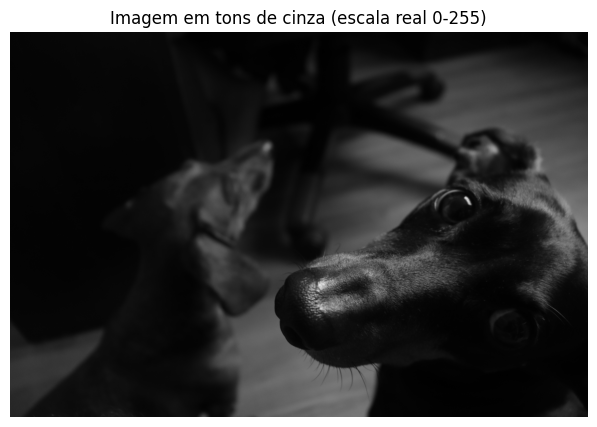

In [31]:
plt.imshow(gray_image, vmin=0, vmax=255)
plt.title('Imagem em tons de cinza (escala real 0-255)')
plt.axis('off')
plt.show()

#### TODO 1.4 — informe altura, largura, canais, dtype, mínimo, máximo e memória ocupada

In [32]:
shape = cv_image.shape
height, width = shape[:2]
channels = shape[2] if cv_image.ndim == 3 else 1
type_ = cv_image.dtype
min_value = cv_image.min()
max_value = cv_image.max()
memory = cv_image.nbytes

print(f"Shape:           {shape}")
print(f"Altura:          {height} px")
print(f"Largura:         {width} px")
print(f"Canais:          {channels}")
print(f"Tipo de dado:    {type_}")
print(f"Valor mínimo:    {min_value}")
print(f"Valor máximo:    {max_value}")
print(f"Memória:         {memory} bytes ({memory / 1024**2:.2f} MB)")

Shape:           (4000, 6000, 3)
Altura:          4000 px
Largura:         6000 px
Canais:          3
Tipo de dado:    uint8
Valor mínimo:    0
Valor máximo:    247
Memória:         72000000 bytes (68.66 MB)


#### TODO 1.5 — exiba lado a lado a imagem colorida e a versão em cinza


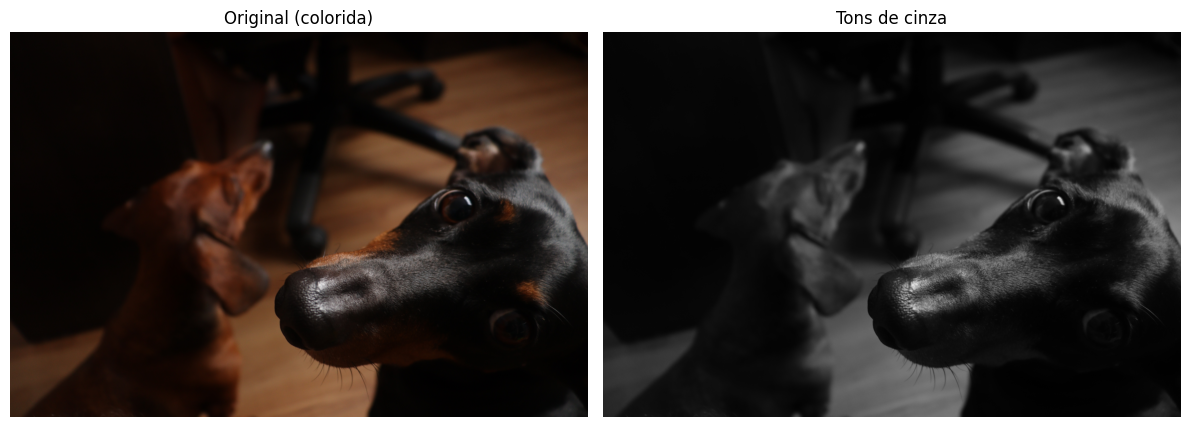

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(cv2.cvtColor(cv_image, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original (colorida)')
axes[0].axis('off')

axes[1].imshow(gray_image, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Tons de cinza')
axes[1].axis('off')

plt.tight_layout()
plt.show()

#### TODO 1.6 — produza histogramas adequados (cinza e/ou por canal)

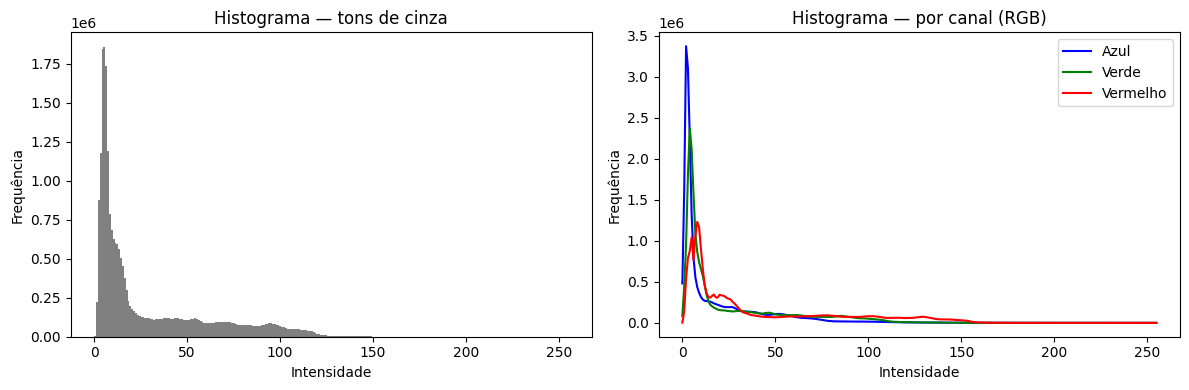

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma em tons de cinza
axes[0].hist(gray_image.ravel(), bins=256, range=(0, 255), color='gray')
axes[0].set_title('Histograma — tons de cinza')
axes[0].set_xlabel('Intensidade')
axes[0].set_ylabel('Frequência')

# Histograma por canal (B, G, R — ordem nativa do OpenCV)
cores = ('b', 'g', 'r')
nomes = ('Azul', 'Verde', 'Vermelho')
for i, (cor, nome) in enumerate(zip(cores, nomes)):
    canal_hist = cv2.calcHist([cv_image], [i], None, [256], [0, 256])
    axes[1].plot(canal_hist, color=cor, label=nome)
axes[1].set_title('Histograma — por canal (RGB)')
axes[1].set_xlabel('Intensidade')
axes[1].set_ylabel('Frequência')
axes[1].legend()

plt.tight_layout()
plt.show()

#### TODO 1.7 - salve o resultado (p1_output_1.jpg)


In [35]:
output_path = OUT_FOLDER / 'p1_output_1.jpg'
sucesso = cv2.imwrite(str(output_path), cv_image)

if not sucesso:
    raise IOError(f"Falha ao salvar imagem em {output_path}")

print(f"Imagem salva em: {output_path.resolve()}")

Imagem salva em: /content/resultados/p1_output_1.jpg


## 2. Realce no domínio espacial
### Objetivos
Aplicar operações diretamente sobre os pixels para melhorar contraste, iluminação ou nitidez. Compare pelo menos duas técnicas, como transformação de intensidade, equalização de histograma, CLAHE, suavização ou aguçamento. (Escolha o que parece mais adequado de acordo com as conclusões feitas em P1)

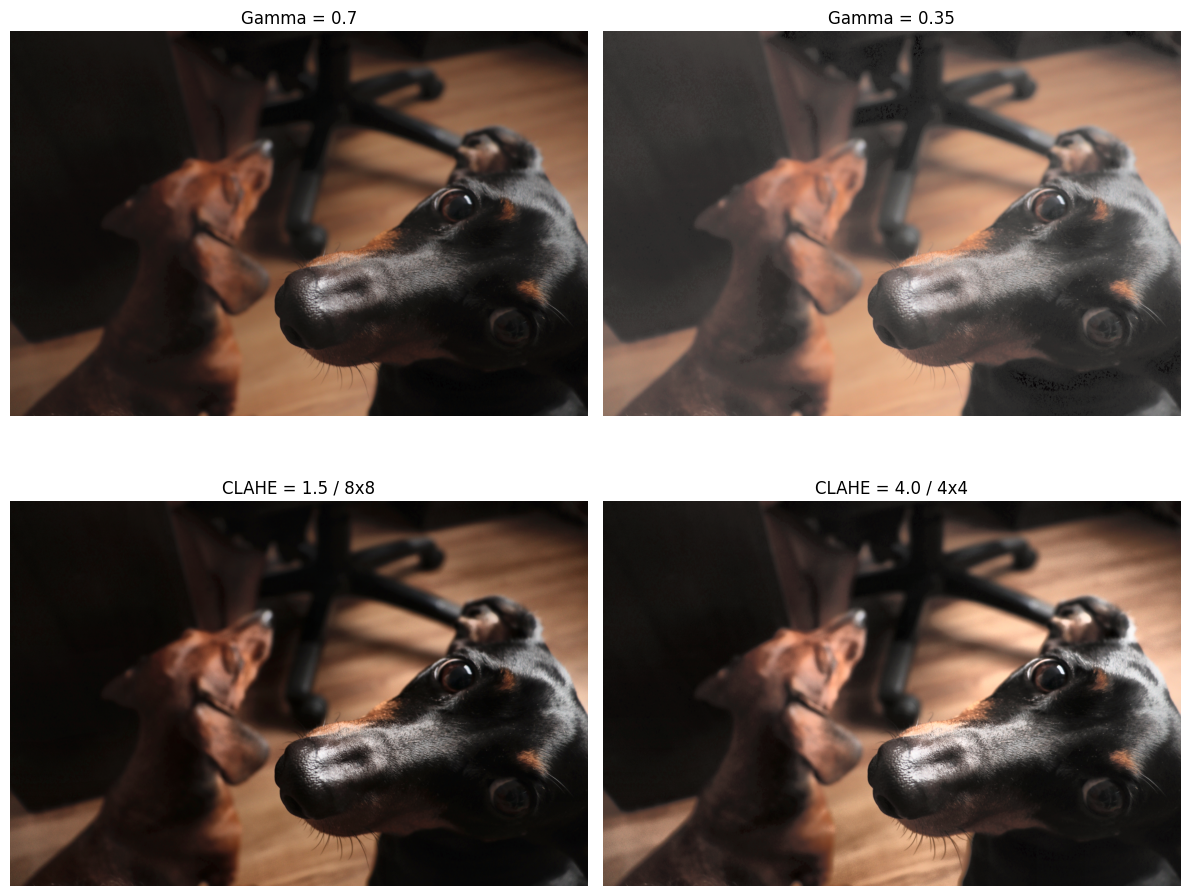

Resultados salvos com sucesso.


In [36]:
# 2.1 — Correção Gamma
def ajustar_gamma(imagem, gamma):
    lab = cv2.cvtColor(imagem, cv2.COLOR_BGR2LAB)
    L, a, b = cv2.split(lab)

    L = np.uint8(255 * (L / 255) ** gamma)

    lab = cv2.merge([L, a, b])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)


realce_1 = ajustar_gamma(cv_image, 0.5)


# 2.2 — CLAHE
def aplicar_clahe(imagem, clip_limit=2.0, grid=(8, 8)):
    lab = cv2.cvtColor(imagem, cv2.COLOR_BGR2LAB)
    L, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=grid)
    L = clahe.apply(L)

    lab = cv2.merge([L, a, b])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)


realce_2 = aplicar_clahe(cv_image, 3.0, (8, 8))


# 2.3 — Comparação de parâmetros
resultados = [
    (ajustar_gamma(cv_image, 0.7), "Gamma = 0.7"),
    (ajustar_gamma(cv_image, 0.35), "Gamma = 0.35"),
    (aplicar_clahe(cv_image, 1.5, (8, 8)), "CLAHE = 1.5 / 8x8"),
    (aplicar_clahe(cv_image, 4.0, (4, 4)), "CLAHE = 4.0 / 4x4")
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (img, titulo) in zip(axes.ravel(), resultados):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(titulo)
    ax.axis("off")

plt.tight_layout()
plt.show()


# 2.4 — Salvar resultados
cv2.imwrite(str(OUT_FOLDER / "p2_output_1.jpg"), realce_1)
cv2.imwrite(str(OUT_FOLDER / "p2_output_2.jpg"), realce_2)

print("Resultados salvos com sucesso.")

## 3. Análise e filtragem no domínio da frequência
### Objetivos
Calcular a Transformada Discreta de Fourier 2D, visualizar o espectro centralizado e projetar uma máscara de filtragem. Use a imagem em cinza e compare um filtro passa-baixas ou passa-altas com o resultado espacial correspondente.

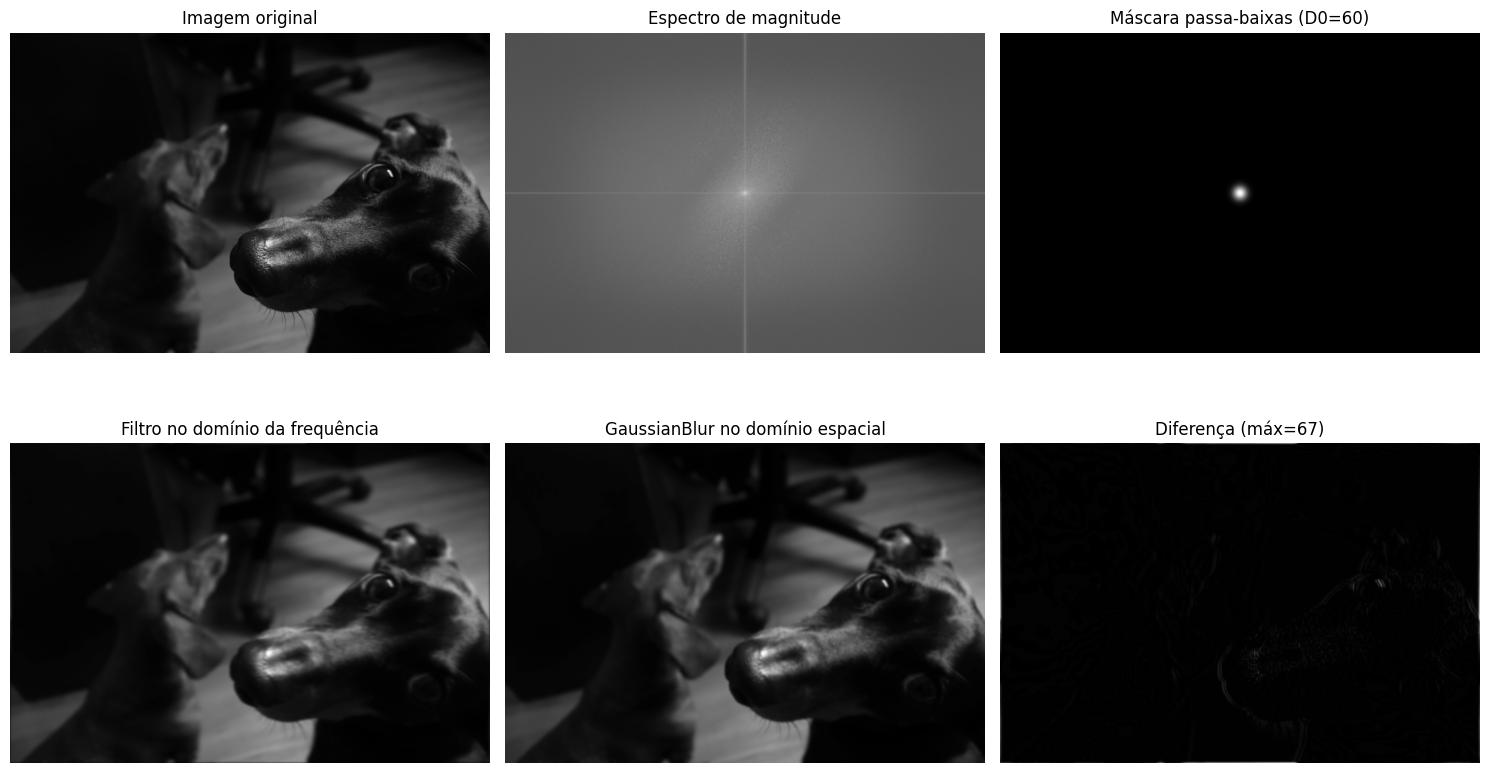

Resultado salvo em: resultados/p3_output_1.jpg


In [37]:
# TODO 3.1 — FFT 2D e centralização das baixas frequências
fft = np.fft.fft2(gray_image)
fft_centralizada = np.fft.fftshift(fft)


# TODO 3.2 — Espectro de magnitude
espectro = np.log1p(np.abs(fft_centralizada))


# TODO 3.3 — Máscara passa-baixas Gaussiana
linhas, colunas = gray_image.shape
centro_linha, centro_coluna = linhas // 2, colunas // 2

D0 = 60  # Quanto menor, maior o desfoque

y, x = np.ogrid[:linhas, :colunas]
distancia = np.sqrt(
    (y - centro_linha) ** 2 +
    (x - centro_coluna) ** 2
)

mascara = np.exp(-(distancia ** 2) / (2 * D0 ** 2))


# TODO 3.4 — Aplicação do filtro e transformada inversa
fft_filtrada = fft_centralizada * mascara

imagem_filtrada = np.fft.ifft2(
    np.fft.ifftshift(fft_filtrada)
)

imagem_filtrada = np.abs(imagem_filtrada)
imagem_filtrada = np.uint8(np.clip(imagem_filtrada, 0, 255))


# TODO 3.5 — Comparação com o desfoque Gaussiano
imagem_gaussiana = cv2.GaussianBlur(
    gray_image,
    (0, 0),
    sigmaX=linhas / (2 * np.pi * D0)
)

diferenca = cv2.absdiff(imagem_filtrada, imagem_gaussiana)


# Visualização
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

imagens = [
    (gray_image, "Imagem original"),
    (espectro, "Espectro de magnitude"),
    (mascara, f"Máscara passa-baixas (D0={D0})"),
    (imagem_filtrada, "Filtro no domínio da frequência"),
    (imagem_gaussiana, "GaussianBlur no domínio espacial"),
    (diferenca, f"Diferença (máx={diferenca.max()})")
]

for ax, (imagem, titulo) in zip(axes.ravel(), imagens):
    ax.imshow(imagem, cmap="gray")
    ax.set_title(titulo)
    ax.axis("off")

plt.tight_layout()
plt.show()


# Salvar resultado
cv2.imwrite(
    str(OUT_FOLDER / "p3_output_1.jpg"),
    imagem_filtrada
)

print("Resultado salvo em:", OUT_FOLDER / "p3_output_1.jpg")

## 4. Degradação e restauração: ruído, MSE e PSNR
### Objetivos
Simular uma degradação controlada, aplicar uma técnica de restauração e medir o resultado. Escolha ruído gaussiano, sal-e-pimenta ou outro modelo estudado. Mantenha a imagem original como referência.

As métricas devem ser implementadas ou aplicadas corretamente

Imagem ruidosa:
MSE: 1355.8831012083333
PSNR: 16.808581128476526

Imagem restaurada:
MSE: 0.9583163333333333
PSNR: 48.315714706367174


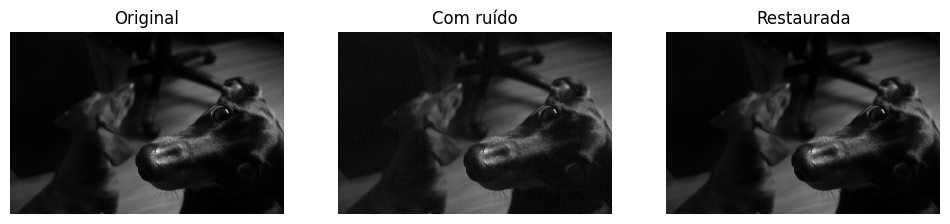

Resultado salvo.


In [38]:
# TODO 4.1 — Adicionar ruído sal e pimenta
def adicionar_ruido(imagem, prob=0.05):
    ruido = np.random.rand(*imagem.shape)
    resultado = imagem.copy()

    resultado[ruido < prob / 2] = 0
    resultado[ruido > 1 - prob / 2] = 255

    return resultado

np.random.seed(42)
imagem_ruidosa = adicionar_ruido(gray_image)


# TODO 4.2 — Restaurar com filtro da mediana
imagem_restaurada = cv2.medianBlur(imagem_ruidosa, 3)

# TODO 4.3 — Calcular MSE e PSNR
def mse(original, imagem):
    return np.mean((original.astype(float) - imagem.astype(float)) ** 2)

def psnr(original, imagem):
    erro = mse(original, imagem)
    return 10 * np.log10(255**2 / erro)


# TODO 4.4 — Resultados
print("Imagem ruidosa:")
print("MSE:", mse(gray_image, imagem_ruidosa))
print("PSNR:", psnr(gray_image, imagem_ruidosa))

print("\nImagem restaurada:")
print("MSE:", mse(gray_image, imagem_restaurada))
print("PSNR:", psnr(gray_image, imagem_restaurada))


# TODO 4.5 — Visualização
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(gray_image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(imagem_ruidosa, cmap="gray")
plt.title("Com ruído")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(imagem_restaurada, cmap="gray")
plt.title("Restaurada")
plt.axis("off")

plt.show()


# Salvar
cv2.imwrite(str(OUT_FOLDER / "p4_output_1.jpg"), imagem_restaurada)
print("Resultado salvo.")

## 5. Processamento em espaço de cor
### Objetivos
Investigar a separação entre luminância e crominância. Converta a fotografia para HSV, Lab ou YCrCb, modifique apenas um componente relevante e reconverta para RGB/BGR. Compare com uma operação equivalente feita diretamente nos canais RGB/BGR.


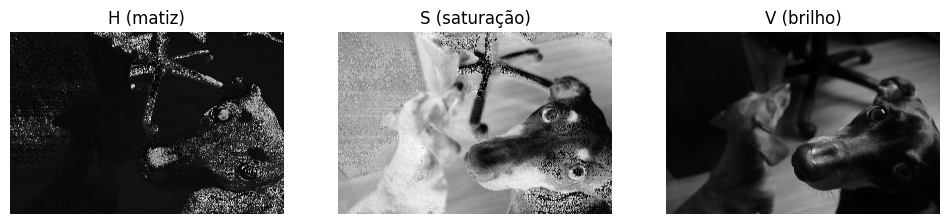

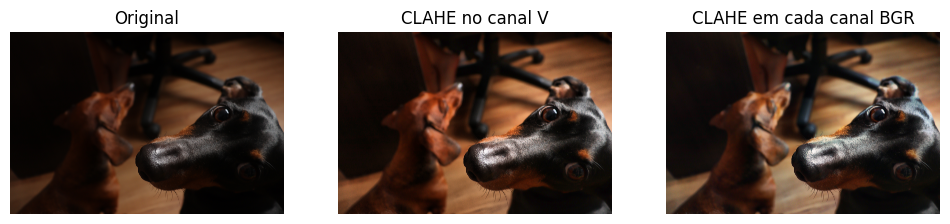

Resultado salvo.


In [39]:
# 5.1 e 5.2 — Converter para HSV e separar os canais
hsv = cv2.cvtColor(cv_image, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(hsv)

# Mostrar os canais
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for eixo, canal, nome in zip(ax, [H, S, V], ["H (matiz)", "S (saturação)", "V (brilho)"]):
    eixo.imshow(canal, cmap="gray")
    eixo.set_title(nome)
    eixo.axis("off")
plt.show()


# 5.3 — Aplicar CLAHE somente no canal V
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
V = clahe.apply(V)


# 5.4 — Reunir os canais e voltar para BGR
resultado = cv2.cvtColor(cv2.merge([H, S, V]), cv2.COLOR_HSV2BGR)


# 5.5 — Comparar resultados
bgr = cv2.merge([clahe.apply(c) for c in cv2.split(cv_image)])

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
imagens = [cv_image, resultado, bgr]
titulos = ["Original", "CLAHE no canal V", "CLAHE em cada canal BGR"]

for eixo, imagem, titulo in zip(ax, imagens, titulos):
    eixo.imshow(cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB))
    eixo.set_title(titulo)
    eixo.axis("off")

plt.show()

cv2.imwrite(str(OUT_FOLDER / "p5_output_1.jpg"), resultado)
print("Resultado salvo.")

## 6. Pipeline final
### Objetivo
Combine apenas as etapas que realmente ajudam a fotografia escolhida. Um pipeline não precisa usar todas as técnicas testadas; precisa ter uma ordem coerente e justificável. Evite múltiplas conversões e salvamentos intermediários com perdas.

Descreva o fluxo planejado, por exemplo: entrada → correção de cor/iluminação → redução de ruído → nitidez → compressão.

Imagem salva em: resultados/p6_output_final.png


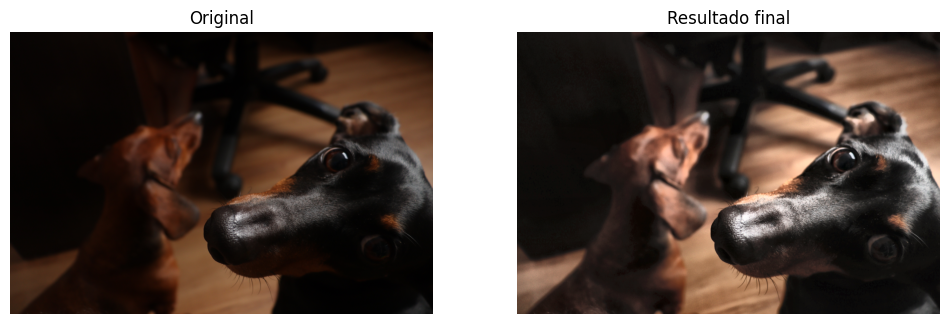

Dimensões: (4000, 6000, 3)
Tamanho do arquivo: 25722.9 KB
Contraste original: 32.34
Contraste final: 55.01
Brilho médio original: 28.55
Brilho médio final: 55.7


In [40]:
def pipeline_fotografia(imagem_bgr):
    """Recebe uma imagem BGR uint8 e retorna a versão final processada."""
    resultado = imagem_bgr.copy()

    # TODO 6.1 — etapa 1: redução de ruído
    # Usa filtro bilateral para reduzir ruído e preservar as bordas.
    lab = cv2.cvtColor(resultado, cv2.COLOR_BGR2LAB)
    L, a, b = cv2.split(lab)
    L = cv2.bilateralFilter(L, 5, 50, 50)

    # TODO 6.2 — etapa 2: melhoria do contraste
    # CLAHE melhora os detalhes, principalmente nas áreas escuras.
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    L = clahe.apply(L)

    resultado = cv2.cvtColor(
        cv2.merge([L, a, b]),
        cv2.COLOR_LAB2BGR
    )

    # TODO 6.3 — etapa 3: aumento de nitidez
    # Reforça as bordas e detalhes da imagem.
    borrada = cv2.GaussianBlur(resultado, (0, 0), 1)
    resultado = cv2.addWeighted(resultado, 1.5, borrada, -0.5, 0)

    return resultado


# TODO 6.4 — execute, cronometre opcionalmente e salve a saída final
imagem_final = pipeline_fotografia(cv_image)

output_path = OUT_FOLDER / "p6_output_final.png"
cv2.imwrite(str(output_path), imagem_final)

print("Imagem salva em:", output_path)


# TODO 6.5 — apresente original e final lado a lado, na mesma escala
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(cv_image, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(imagem_final, cv2.COLOR_BGR2RGB))
plt.title("Resultado final")
plt.axis("off")

plt.show()


# TODO 6.6 — informe dimensões, tamanho do arquivo final e métricas aplicáveis
cinza_original = cv2.cvtColor(cv_image, cv2.COLOR_BGR2GRAY)
cinza_final = cv2.cvtColor(imagem_final, cv2.COLOR_BGR2GRAY)

print("Dimensões:", imagem_final.shape)
print("Tamanho do arquivo:", round(output_path.stat().st_size / 1024, 1), "KB")
print("Contraste original:", round(cinza_original.std(), 2))
print("Contraste final:", round(cinza_final.std(), 2))
print("Brilho médio original:", round(cinza_original.mean(), 2))
print("Brilho médio final:", round(cinza_final.mean(), 2))